<a href="https://colab.research.google.com/github/ggtorres/Machine-Learning/blob/main/Machine_Learning_inclus%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Finance - Exploração de Dados e Machine Learning

**Curso:** MBA Data Science & Artificial Intelligence

**Matéria:** Machine Learning

Projeto Integrado

**Alunos:**

Guilherme Torres Guedes - RM: 363544

Johnny Mendes Alves - RM: 364028

Sabrina Terezinha Dresch da Silva - RM: 363519

## Bibliotecas e Parâmetros

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import silhouette_score

# Instação as bibliotecas e parâmetros do kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

## Carregamento da Base

In [ ]:
# Definindo o arquivo
file_path = "train.csv"

# Carregando versão mais recente
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "parisrohan/credit-score-classification",
  file_path,
)

/tmp/ipython-input-2507832930.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'credit-score-classification' dataset.


/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:91: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


##  EDA (ANÁLISE EXPLORATÓRIA DA BASE)

---

In [ ]:
# dimensões da base
print(df.shape)

(100000, 28)


In [ ]:
# observando as 5 primeiras linhas do df treino
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
print(list(df))

['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


`'ID'` - Represents a unique identification of an entry

`'Customer_ID'`- Represents a unique identification of a person

`'Month'` - Represents the month of the year

`'Name'` - Represents the name of a person

`'Age'`- Represents the age of the person

`'SSN'` - Represents the social security number of a person

 `'Occupation'` - Represents the occupation of the person

`'Annual_Income'` - Represents the annual income of the person

`'Monthly_Inhand_Salary'` - Represents the monthly base salary of a person

`'Num_Bank_Accounts'` - Represents the number of bank accounts a person holds

`'Num_Credit_Card'` - Represents the number of other credit cards held by a person

`'Interest_Rate'` - Represents the interest rate on credit card

`'Num_of_Loan'` - Represents the number of loans taken from the bank

`'Type_of_Loan'` - Represents the types of loan taken by a person

`'Delay_from_due_date'` - Represents the average number of days delayed from the payment date

`'Num_of_Delayed_Payment'` - Represents the average number of payments delayed by a person

`'Changed_Credit_Limit'` - Represents the percentage change in credit card limit

`'Num_Credit_Inquiries'` - Represents the number of credit card inquiries

`'Credit_Mix'` - Represents the classification of the mix of credits

`'Outstanding_Debt'` - Represents the remaining debt to be paid (in USD)

`'Credit_Utilization_Ratio'` - Represents the utilization ratio of credit card

`'Credit_History_Age'` - Represents the age of credit history of the person

`'Payment_of_Min_Amount'` - Represents whether only the minimum amount was paid by the person

`'Total_EMI_per_month'` - Represents the monthly EMI payments (in USD)

`'Amount_invested_monthly'` - Represents the monthly amount invested by the customer (in USD)

`'Payment_Behaviour'` - Represents the payment behavior of the customer (in USD)

`'Monthly_Balance'` - Represents the monthly balance amount of the customer (in USD)

`'Credit_Score'` - Represents the bracket of credit score (Poor, Standard, Good)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
# verificando o resumo estatístico
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


`'Monthly_Inhand_Salary'`- o fato de termos 17.207 registros já nos mostra a presença de **missing values**. A média do salário líquido mensal é de 4.288 enquanto a mediana é de 3.177, isso já mostra que possivelmente temos uma **assimentria à direita**, enquanto a maioria das pessoas ganha próximos aos 3.000 existem algumas pessoas com salários mais altos, elevando assim a média geral.

`'Num_Bank_Accounts'` - o valor máximo de número de contas é de 1.789, nesse caso é bem provável que tenha ocorrido um erro de registro.

`'Num_Credit_Card'` - aqui também possuímos dados estranhos, sendo que o maior número de cartões de crédito é de 1.498.

`'Interest_Rate'` - o mesmo caso ocorre aqui, a média da taxa de juros do cartão de crédito está em 68.

`'Delay_from_due_date'` - aqui temos como valor mínimo um número negativo.

`'Num_Credit_Inquiries'`- 2.594 como valor máximo em consulta de cédito realizada, também é um valor muito alto

`'Credit_Utilization_Ratio'` - a mediana está em 32, entretanto há um alto desvio padrão e a média sendo puxada para cima.

`'Total_EMI_per_month'` - o valor máximo de parcelas pagas por mês está em 82.256, porém o salário médio é de 4.288, o que chama atenção por ser uma diferença grande.

In [ ]:
# valores nulos
print((df.isnull().sum() / df.shape[0]).sort_values(ascending=False))

Monthly_Inhand_Salary       0.15002
Type_of_Loan                0.11408
Name                        0.09985
Credit_History_Age          0.09030
Num_of_Delayed_Payment      0.07002
Amount_invested_monthly     0.04479
Num_Credit_Inquiries        0.01965
Monthly_Balance             0.01200
Month                       0.00000
Age                         0.00000
Customer_ID                 0.00000
ID                          0.00000
Interest_Rate               0.00000
Num_Credit_Card             0.00000
Num_Bank_Accounts           0.00000
Annual_Income               0.00000
SSN                         0.00000
Occupation                  0.00000
Delay_from_due_date         0.00000
Num_of_Loan                 0.00000
Outstanding_Debt            0.00000
Credit_Mix                  0.00000
Changed_Credit_Limit        0.00000
Credit_Utilization_Ratio    0.00000
Total_EMI_per_month         0.00000
Payment_of_Min_Amount       0.00000
Payment_Behaviour           0.00000
Credit_Score                

Possuímos 8 variáveis com valores nulos.

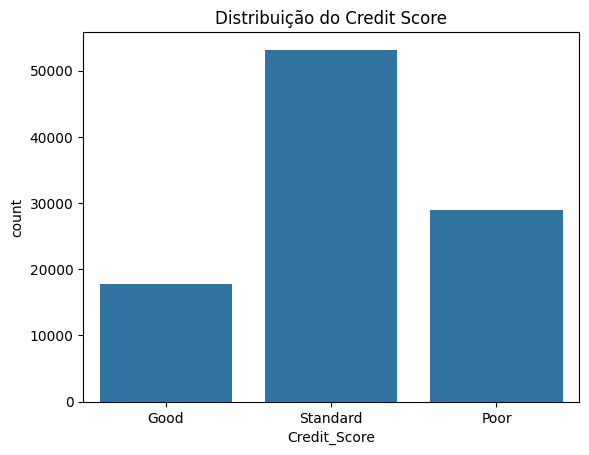

In [ ]:
sns.countplot(data=df, x='Credit_Score')
plt.title("Distribuição do Credit Score")
plt.show()

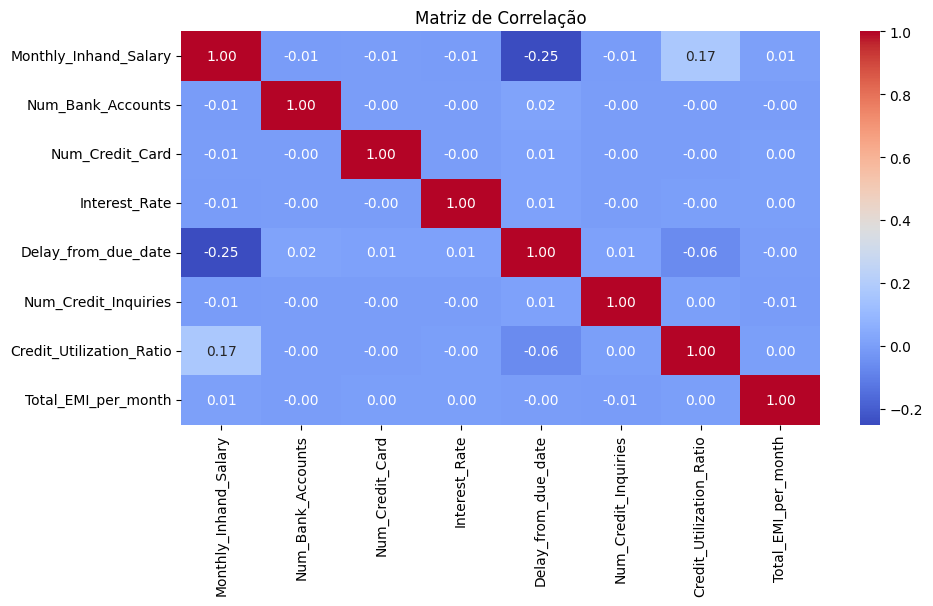

In [ ]:
num_cols = df.select_dtypes(include='number')
corr = num_cols.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.tight_layout()
plt.title("Matriz de Correlação")
plt.show()

A maioria das correlações é baixa, indicando pouca multicolinearidade forte.

Existe uma correlação forte entre `Annual_Income` × `Monthly_Inhand_Salary` (0.87), ou seja, são praticamente a mesma informação em escalas diferentes e traz uma forte redundância.

##  PREPARAÇÃO DOS DADOS

---



In [ ]:
# Remoção de colunas irrelevantes
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Limpeza de colunas numéricas com valores inconsistentes
numeric_cols = [
    'Age', 'Annual_Income', 'Num_of_Loan',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance'
]

def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    cleaned = re.sub(r'[^0-9.\-]', '', str(val))
    try:
        value = float(cleaned)
        return value if -10 < value < 1_000_000 else np.nan
    except:
        return np.nan

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# Tratamento de valores nulos
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Foi adotado um limite superior empírico para remoção de valores inconsistentes extremos

##  MODELOS DE CLASSIFICAÇÃO (SUPERVISIONADO)

In [ ]:
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

# encode do target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
target_names = le_target.classes_

# tratamento
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str)

# split entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# separando em categóricas e numéricas
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# inputação, enconding e scaling
numeric_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor_lr = ColumnTransformer(transformers=[('num', numeric_pipeline, num_cols), ('cat', categorical_pipeline, cat_cols)])

# modelo
log_reg = Pipeline(steps=[('preprocessor', preprocessor_lr),('model', LogisticRegression(max_iter=1000, random_state=42))])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# métricas
print("Logistic Regression")
print(f"Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

Logistic Regression
Acurácia: 0.7255
              precision    recall  f1-score   support

        Good       0.59      0.60      0.60      3566
        Poor       0.77      0.69      0.73      5799
    Standard       0.75      0.79      0.77     10635

    accuracy                           0.73     20000
   macro avg       0.70      0.69      0.70     20000
weighted avg       0.73      0.73      0.73     20000



Modelo de regressão logística apresentou uma acurácia de 72%

- `GOOD`: de todos que eram good, ele acertou 60%

- `POOR`: de todos que eram poor, ele acertou 69%, quando o modelo prevê poor ele acerta 77%

- `STANDARD`: de todos que eram standard, ele acertou 79%

In [ ]:
# inputação e enconding
numeric_pipeline_rf = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline_rf = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor_rf = ColumnTransformer(transformers=[('num', numeric_pipeline_rf, num_cols), ('cat', categorical_pipeline_rf, cat_cols)])

# modelo
rf_model = Pipeline(steps=[('preprocessor', preprocessor_rf), ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# métricas
print("Random Forest")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

Random Forest
Acurácia: 0.7591
              precision    recall  f1-score   support

        Good       0.69      0.69      0.69      3566
        Poor       0.77      0.74      0.75      5799
    Standard       0.78      0.80      0.79     10635

    accuracy                           0.76     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.76      0.76      0.76     20000



Modelo de random forest apresentou uma acurácia de 75%

- `GOOD`: de todos que eram good, ele acertou 69%

- `POOR`: de todos que eram poor, ele acertou 74%, quando o modelo prevê poor ele acerta 77%

- `STANDARD`: de todos que eram standard, ele acertou 80%

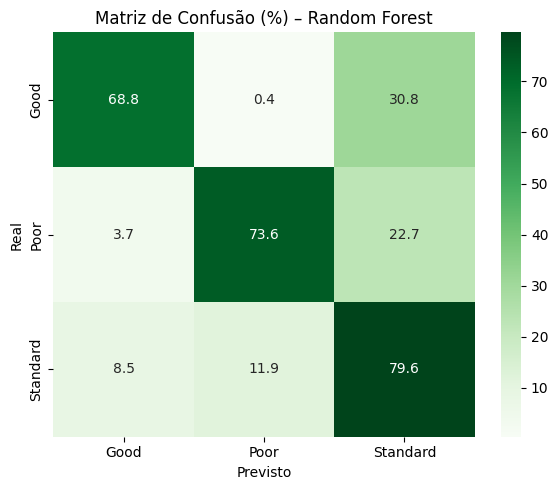

In [ ]:
# matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)

# normalização por linha (percentual)
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap='Greens',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Matriz de Confusão (%) – Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

- `GOOD`: 68.8% dos clientes 'good' foram corretamente classificados, 0.4% foram classificados como 'poor', mas eram 'good' e 30.8% foram classificados como 'standard', mas eram 'good'

- `POOR`: 73.6% dos clientes 'poor' foram corretamente classificados, 3.7% foram classificados como 'good', mas eram 'poor' e 22.7% foram classificados como 'standard', mas eram 'poor'

- `STANDARD`: 79.6% dos clientes 'standard' foram corretamente classificados, 8.5% foram classificados como 'good', mas eram 'standard' e 11.9% foram classificados como 'poor', mas eram 'standard'.

Podemos ver que existe uma certa confusão entre good e standard. Ainda assim o uso do random forest supera a regressão logística em todos os pontos críticos, especialmente na classe Poor, que é a mais sensível ao negócio.

## AGRUPAMENTO DE PERFIS (NÃO SUPERVISIONADO – K-MEANS)

In [ ]:
cluster_features = ['Annual_Income', 'Outstanding_Debt', 'Num_of_Delayed_Payment']

X_cluster = df[cluster_features].copy()

X_cluster = SimpleImputer(strategy='median').fit_transform(X_cluster)
X_cluster = StandardScaler().fit_transform(X_cluster)

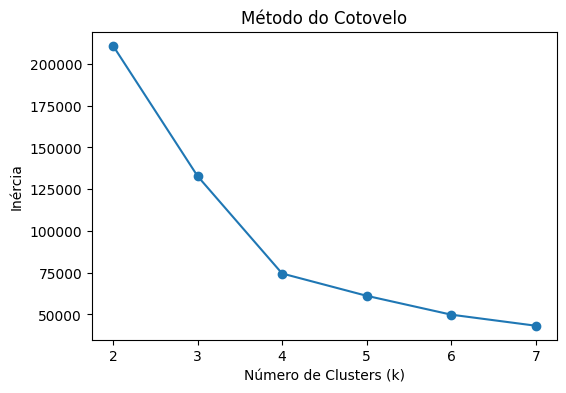

In [ ]:
# metodo do cotovelo para decidir o k
inertias = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()


É possível identificar que após 4 a curva fica achatada, ou seja, o aumento no número de clusters não resulta em melhora significativa.

Com isso, vamos optar por seguir com 3.

In [ ]:
# aplicando o kmeans com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

df.groupby('Cluster')[cluster_features].mean().round(2)

,Annual_Income,Outstanding_Debt,Num_of_Delayed_Payment
Cluster,,,
0,58225.47,838.65,13.19
1,55381.52,1342.16,2894.83
2,30206.18,2982.10,19.67


In [ ]:

# métrica que mede a coesão interna do cluster e a separação deles
# > 0.5 muito bom
# 0.3 - 0.5 - bom
# < 0.3 - fraco
sil_score = silhouette_score(X_cluster, df['Cluster'])
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.4103


Nesse caso 0.41 indica que existe uma boa separação entre os clusters, existe uma coesão e uma sobreposição moderada.

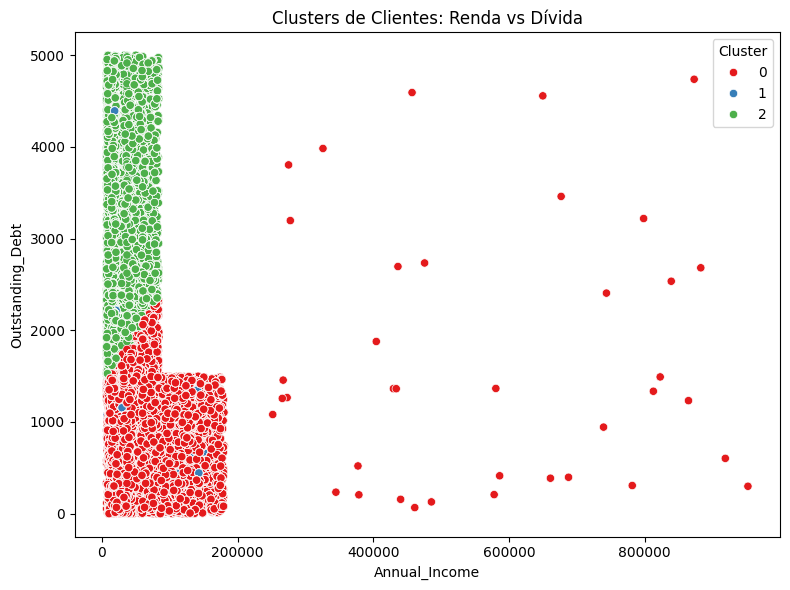

In [ ]:

# Visualização dos clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Outstanding_Debt',
    hue='Cluster',
    palette='Set1'
)
plt.title("Clusters de Clientes: Renda vs Dívida")
plt.tight_layout()
plt.show()